In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve

# Load dataset
df = pd.read_csv("/content/final_dataset_after_feature_selection_in_xgboost.csv")

# Sort by time
df = df.sort_values("TransactionDT").reset_index(drop=True)

df.drop(columns=['TransactionDT'], inplace=True)

In [ ]:
schema_dict = df.dtypes.apply(lambda x: x.name).to_dict()
print(schema_dict)

{'id_01': 'float64', 'id_02': 'float64', 'id_03': 'float64', 'id_04': 'float64', 'id_05': 'float64', 'id_06': 'float64', 'id_09': 'float64', 'id_10': 'float64', 'id_11': 'float64', 'id_13': 'float64', 'id_14': 'float64', 'id_17': 'float64', 'id_18': 'float64', 'id_19': 'float64', 'id_20': 'float64', 'id_32': 'float64', 'TransactionAmt': 'float64', 'card1': 'int64', 'card2': 'float64', 'card3': 'float64', 'card5': 'float64', 'addr1': 'float64', 'addr2': 'float64', 'dist2': 'float64', 'C1': 'float64', 'C2': 'float64', 'C3': 'float64', 'C4': 'float64', 'C6': 'float64', 'C7': 'float64', 'C8': 'float64', 'C10': 'float64', 'C11': 'float64', 'C12': 'float64', 'C13': 'float64', 'C14': 'float64', 'D1': 'float64', 'D4': 'float64', 'D5': 'float64', 'D6': 'float64', 'D7': 'float64', 'D8': 'float64', 'D9': 'float64', 'D10': 'float64', 'D12': 'float64', 'D13': 'float64', 'D14': 'float64', 'D15': 'float64', 'V12': 'float64', 'V13': 'float64', 'V14': 'float64', 'V15': 'float64', 'V16': 'float64', 'V17

In [ ]:
print(len(schema_dict))

493


In [ ]:
df.shape

(144233, 493)

In [ ]:


# Train / Test split (80-20)
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df  = df.iloc[split_index:]

X_train = train_df.drop(columns=["isFraud"])
y_train = train_df["isFraud"]

X_test_xgb = test_df.drop(columns=["isFraud"])
y_test = test_df["isFraud"]

# Train / Validation split from train (time based)
val_split = int(len(X_train) * 0.8)

X_train_final = X_train.iloc[:val_split]
X_val = X_train.iloc[val_split:]

y_train_final = y_train.iloc[:val_split]
y_val = y_train.iloc[val_split:]

scale_pos_weight = (y_train_final == 0).sum() / (y_train_final == 1).sum()

model = xgb.XGBClassifier(
    learning_rate=0.01,
    n_estimators=2000,
    max_depth=4,
    min_child_weight=20,
    gamma=5,
    subsample=0.7,
    colsample_bytree=0.5,
    reg_alpha=5,
    reg_lambda=20,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=100
)

model.fit(
    X_train_final,
    y_train_final,
    eval_set=[(X_val, y_val)],
    verbose=100
)

train_preds = model.predict_proba(X_train_final)[:,1]
val_preds = model.predict_proba(X_val)[:,1]
test_preds = model.predict_proba(X_test_xgb)[:,1]

print("\n===== AUC Scores =====")
print("Train AUC:", roc_auc_score(y_train_final, train_preds))
print("Validation AUC:", roc_auc_score(y_val, val_preds))
print("Test AUC:", roc_auc_score(y_test, test_preds))

precision, recall, thresholds = precision_recall_curve(y_val, val_preds)
f1_scores = 2 * precision * recall / (precision + recall + 1e-10)

best_threshold = thresholds[np.argmax(f1_scores)]
print("\nBest Threshold:", best_threshold)

y_test_pred_label = (test_preds > best_threshold).astype(int)

print("\n===== Classification Report (Test) =====")
print(classification_report(y_test, y_test_pred_label))

[0]	validation_0-auc:0.88921
[100]	validation_0-auc:0.93597
[200]	validation_0-auc:0.94168
[300]	validation_0-auc:0.94741
[400]	validation_0-auc:0.95163
[500]	validation_0-auc:0.95510
[600]	validation_0-auc:0.95724
[700]	validation_0-auc:0.95935
[800]	validation_0-auc:0.96070
[900]	validation_0-auc:0.96188
[1000]	validation_0-auc:0.96297
[1100]	validation_0-auc:0.96393
[1200]	validation_0-auc:0.96471
[1300]	validation_0-auc:0.96540
[1400]	validation_0-auc:0.96601
[1500]	validation_0-auc:0.96642
[1600]	validation_0-auc:0.96692
[1700]	validation_0-auc:0.96714
[1800]	validation_0-auc:0.96758
[1900]	validation_0-auc:0.96793
[1999]	validation_0-auc:0.96819

===== AUC Scores =====
Train AUC: 0.989211722265502
Validation AUC: 0.968193270486059
Test AUC: 0.9484714525104518

Best Threshold: 0.7849556

===== Classification Report (Test) =====
              precision    recall  f1-score   support

           0       0.97      0.96      0.97     26175
           1       0.67      0.73      0.70   

In [ ]:
import pandas as pd

xgb_preds = pd.DataFrame({
    "y_true": y_test,
    "pred_xgb": test_preds
})

xgb_preds.to_csv("xgb_predictions.csv", index=False)

In [ ]:
from sklearn.metrics import classification_report

# Use same best threshold you found
train_pred_labels = (train_preds > best_threshold).astype(int)

print("\n===== Classification Report (Train) =====")
print(classification_report(y_train_final, train_pred_labels))


===== Classification Report (Train) =====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     86244
           1       0.82      0.84      0.83      6064

    accuracy                           0.98     92308
   macro avg       0.90      0.91      0.91     92308
weighted avg       0.98      0.98      0.98     92308



In [ ]:
# training data report for thresold =0.688


from sklearn.metrics import precision_recall_curve
import numpy as np
precision, recall, thresholds = precision_recall_curve(y_val, val_preds)

# Find threshold where recall >= 0.80

target_recall = 0.80

idx = np.where(recall >= target_recall)[0][-1]
new_threshold = thresholds[idx]

print("New Threshold:", new_threshold)
print("Precision at that point:", precision[idx])
print("Recall at that point:", recall[idx])

New Threshold: 0.7151844
Precision at that point: 0.7480086893555394
Recall at that point: 0.8001549186676995


In [ ]:
# testing data report  for new threshold

# y_test_pred_label = (test_preds > 0.4).astype(int)

y_test_pred_label = (test_preds > new_threshold).astype(int)

print(classification_report(y_test, y_test_pred_label))
from sklearn.metrics import roc_auc_score

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     26175
           1       0.60      0.79      0.68      2672

    accuracy                           0.93     28847
   macro avg       0.79      0.87      0.82     28847
weighted avg       0.94      0.93      0.94     28847



In [ ]:
#final AUC

# Train AUC
train_auc = roc_auc_score(y_train_final, train_preds)
print("Train AUC:", train_auc)

# Test AUC
test_auc = roc_auc_score(y_test, test_preds)
print("Test AUC:", test_auc)

Train AUC: 0.989211722265502
Test AUC: 0.9484714525104518


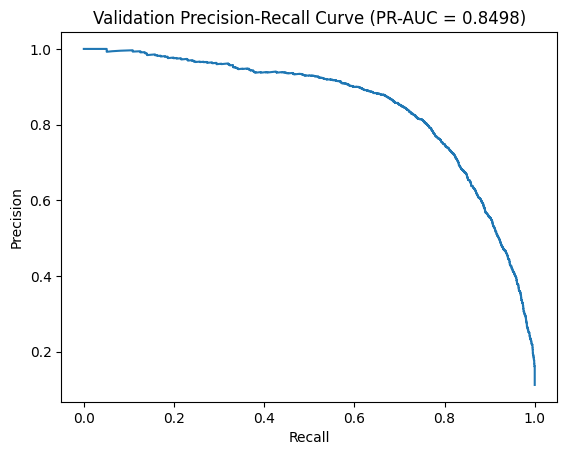

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Compute curve
precision, recall, _ = precision_recall_curve(y_val, val_preds)
pr_auc = average_precision_score(y_val, val_preds)

# Plot
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Validation Precision-Recall Curve (PR-AUC = {pr_auc:.4f})")
plt.show()

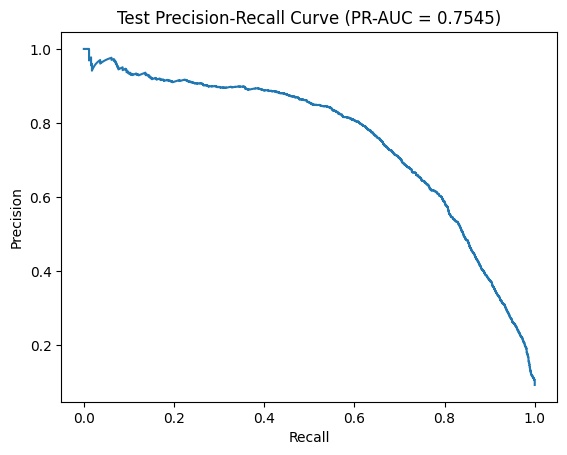

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, test_preds)
pr_auc = average_precision_score(y_test, test_preds)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Test Precision-Recall Curve (PR-AUC = {pr_auc:.4f})")
plt.show()

In [ ]:
import pickle

filename = 'fraud_model.sav'
pickle.dump(model, open(filename, 'wb'))

In [ ]:
loaded_model = pickle.load(open('fraud_model.sav', 'rb'))